# 隨機森林 (Random Forest)

學習目標：
- 了解決策樹的原理
- 理解隨機森林為什麼比單棵樹好
- 學會用特徵重要性找出關鍵指標

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

## 1. 決策樹直覺

決策樹就像一連串的「是/否」問題：
  訓練時數 > 20？
    → 是：成績 > 85？→ 菁英 / 一般
    → 否：年齡 < 25？→ 菁英 / 一般

問題：單棵決策樹容易過擬合（記住訓練資料）

解決：隨機森林 = 很多棵樹投票決定結果

In [3]:
# 建立模擬運動員資料（5個特徵）
np.random.seed(42)
n = 500

data = {
    '訓練時數':  np.random.uniform(5, 30, n),
    '睡眠時數':  np.random.uniform(5, 9, n),
    '年齡':      np.random.uniform(18, 35, n),
    '比賽次數':  np.random.randint(1, 50, n).astype(float),
    '體能評分':  np.random.uniform(60, 100, n),
}

X = np.column_stack(list(data.values()))
feature_names = list(data.keys())

# 菁英選手條件：訓練時數>20 且 體能評分>80
y = ((data['訓練時數'] > 20) &
     (data['體能評分'] > 80)).astype(int)

print(f'菁英選手：{y.sum()} 位')
print(f'一般選手：{(y==0).sum()} 位')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

菁英選手：100 位
一般選手：400 位


In [4]:
# 比較單棵決策樹 vs 隨機森林
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print(f'{"模型":<15} {"Accuracy":>10}')
print('-' * 27)
for name, model in [('決策樹', dt), ('隨機森林', rf)]:
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f'{name:<15} {acc:>10.3f}')

模型                Accuracy
---------------------------
決策樹                  0.980
隨機森林                 0.960


## 2. 特徵重要性

隨機森林可以告訴我們：
「哪個特徵對分類最有幫助？」

這跟你 AHP 論文找關鍵指標的概念很像，
差別是：
- AHP：靠專家主觀判斷指標重要性
- 隨機森林：從資料客觀計算指標重要性

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39636 (\N{CJK UNIFIED IDEOGRAPH-9AD4}) missing from font(s) DejaVu Sans.
  fig.canvas

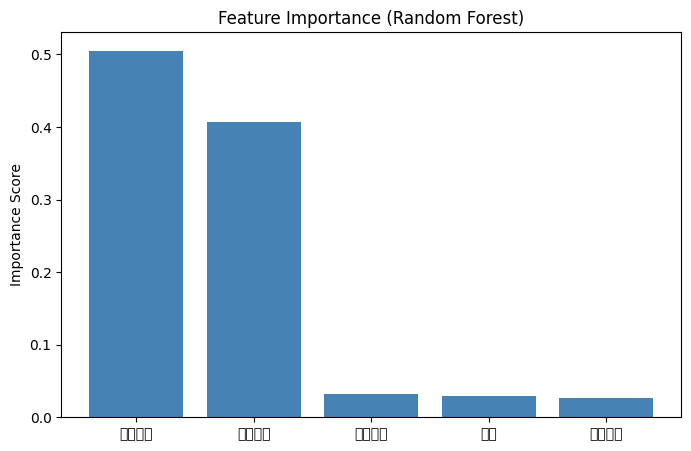

特徵重要性排名：
  訓練時數    : 0.505
  體能評分    : 0.407
  睡眠時數    : 0.032
  年齡      : 0.029
  比賽次數    : 0.026


In [5]:
# 特徵重要性
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(range(len(feature_names)),
        importances[indices], color='steelblue')
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices])
plt.title('Feature Importance (Random Forest)')
plt.ylabel('Importance Score')
plt.show()

print('特徵重要性排名：')
for i in indices:
    print(f'  {feature_names[i]:<8}: {importances[i]:.3f}')

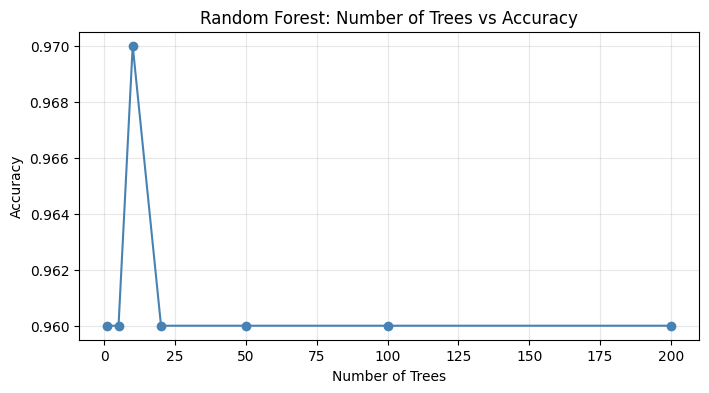

In [6]:
# 樹的數量 vs 準確率
n_trees = [1, 5, 10, 20, 50, 100, 200]
accuracies = []

for n in n_trees:
    rf_temp = RandomForestClassifier(
        n_estimators=n, random_state=42)
    rf_temp.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf_temp.predict(X_test))
    accuracies.append(acc)

plt.figure(figsize=(8, 4))
plt.plot(n_trees, accuracies, 'o-', color='steelblue')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest: Number of Trees vs Accuracy')
plt.grid(alpha=0.3)
plt.show()

## 3. 我的學習筆記

1. 這個主題在做什麼：
   用很多棵決策樹投票，比單棵樹更準確、更穩定。
   同時可以用特徵重要性找出最關鍵的指標。

2. 隨機森林的兩大優點：
   - 準確率高，不容易過擬合
   - 特徵重要性可解釋模型決策

3. 我覺得最難理解的地方：
   這個很重要，需要熟練
  

4. 這個跟我研究的連結：
   我的碩士論文用 AHP 找運動員選才關鍵指標，
   隨機森林的特徵重要性可以做資料驅動的驗證：
   「資料說這些指標重要，跟專家判斷一致嗎？」
   這個對比分析可以直接放進博士班申請書。